#Importación de librerias

In [4]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

In [6]:
# Configuración inicial
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

# =============================================================================
# 0. DESCARGA DEL DATASET
# =============================================================================
DATASET_URL = "https://raw.githubusercontent.com/No-Country-simulation/Hackaton_G9_Server_2_Team27/refs/heads/main/data/dataset_bruto_final.csv"
RAW_DATA_PATH = "dataset_bruto_final.csv"

# Descarga local del dataset
df_raw = pd.read_csv(DATASET_URL)
df_raw.to_csv(RAW_DATA_PATH, index=False)
print(f"Dataset descargado y guardado en: {RAW_DATA_PATH}")



Dataset descargado y guardado en: dataset_bruto_final.csv


In [8]:
# =============================================================================
# 1. EDA Y ETL (Limpieza Inicial)
# =============================================================================
df = pd.read_csv(RAW_DATA_PATH)

print("="*70)
print("1. EDA - RESUMEN GENERAL")
print("="*70)
print(f"Dimensiones: {df.shape}")
print(f"\nValores nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
print(f"\nDistribución de la variable objetivo (categoria):")
print(df["categoria"].value_counts())

# --- Hallazgo de Data Leakage y Redundancia ---
# Exclusión de 'energy_efficiency_score', 'costo_estimado' y 'tarifa_kwh' por las razones analizadas en EDA
cols_to_drop = ["energy_efficiency_score", "costo_estimado", "tarifa_kwh"]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Imputación de nulos (Mediana)
cols_nulas = ["antiguedad_vivienda", "horas_en_casa", "ingreso_mensual", "electrodomesticos_eficientes"]
for c in cols_nulas:
    df[c] = df[c].fillna(df[c].median())

# Guardar dataset limpio post-ETL básico
os.makedirs("./data", exist_ok=True)
RUTA_DATASET_LIMPIO = "./data/dataset_limpio_modeloknn_refactorizado.csv"
df.to_csv(RUTA_DATASET_LIMPIO, index=False)
print(f"\nDataset limpio (post-ETL) guardado en: {RUTA_DATASET_LIMPIO}")

# Codificación del Target (y)
le_y = LabelEncoder()
y = le_y.fit_transform(df["categoria"])
print(f"Clases codificadas: {dict(zip(le_y.classes_, range(len(le_y.classes_))))}")



1. EDA - RESUMEN GENERAL
Dimensiones: (10000, 33)

Valores nulos por columna:
antiguedad_vivienda             454
horas_en_casa                   287
ingreso_mensual                 435
electrodomesticos_eficientes    273
dtype: int64

Filas duplicadas: 0

Distribución de la variable objetivo (categoria):
categoria
Moderate       4495
Efficient      3003
Inefficient    2502
Name: count, dtype: int64

Dataset limpio (post-ETL) guardado en: ./data/dataset_limpio_modeloknn.csv
Clases codificadas: {'Efficient': 0, 'Inefficient': 1, 'Moderate': 2}


In [9]:
# =============================================================================
# 2. DEFINICIÓN DE FEATURES Y MUTUAL INFORMATION
# =============================================================================
# Para el cálculo de Mutual Information transformamos temporalmente a numérico
df_mi = df.copy()
df_mi["aislamiento_enc"] = df_mi["aislamiento"].map({"Poor": 0, "Average": 1, "Good": 2, "Excellent": 3})
df_mi["eficiencia_construccion_enc"] = df_mi["eficiencia_construccion"].map({"E": 0, "D": 1, "C": 2, "B": 3, "A": 4})
df_mi = pd.get_dummies(df_mi, columns=["tipo_calefaccion", "tipo_iluminacion"], drop_first=True)

candidate_cols = [
    "metros_cuadrados", "habitaciones", "baños", "antiguedad_vivienda", "aislamiento_enc",
    "eficiencia_construccion_enc", "paneles_solares", "cantidad_personas", "trabajo_remoto",
    "horas_en_casa", "ingreso_mensual", "aires_acondicionados", "heladeras", "televisores",
    "computadoras", "lavadoras", "secadoras", "cantidad_equipos", "calefaccion",
    "electrodomesticos_eficientes", "temperatura_media", "consumo_kwh", "uso_horario_pico",
    "horas_alto_consumo"
] + [c for c in df_mi.columns if c.startswith("tipo_iluminacion_") or c.startswith("tipo_calefaccion_")]

mi_scores = mutual_info_classif(df_mi[candidate_cols], y, random_state=RANDOM_STATE)
mi_ranking = pd.Series(mi_scores, index=candidate_cols).sort_values(ascending=False)

# Selección de características en su estado original (pre-transformación)
# Seleccionamos las columnas correspondientes en el dataframe crudo `df`
NUMERIC_FEATURES = [
    "antiguedad_vivienda", "electrodomesticos_eficientes",
    "cantidad_personas", "consumo_kwh", "horas_en_casa", "trabajo_remoto"
]
ORDINAL_FEATURES = ["aislamiento", "eficiencia_construccion"]
NOMINAL_FEATURES = ["tipo_calefaccion", "tipo_iluminacion"]

ALL_SELECTED_FEATURES = NUMERIC_FEATURES + ORDINAL_FEATURES + NOMINAL_FEATURES

X = df[ALL_SELECTED_FEATURES]


In [10]:

# =============================================================================
# 3. PREPARACIÓN DEL PIPELINE DE PREPROCESAMIENTO (Scikit-Learn)
# =============================================================================
# Definición de jerarquías para variables ordinales
categories_aislamiento = ["Poor", "Average", "Good", "Excellent"]
categories_eficiencia = ["E", "D", "C", "B", "A"]

# Preprocesador con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), NUMERIC_FEATURES),
        ("ord", OrdinalEncoder(categories=[categories_aislamiento, categories_eficiencia]), ORDINAL_FEATURES),
        ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL_FEATURES)
    ],
    remainder="drop"
)

# Pipeline de producción completo
full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])



In [11]:
# =============================================================================
# 4. DIVISIÓN Y BÚSQUEDA DE HIPERPARÁMETROS (GRIDSEARCHCV)
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Definición de la grilla referenciando el paso 'classifier' del Pipeline
param_grid = {
    "classifier__n_neighbors": list(range(5, 32, 2)),
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"],
}

grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_

print("\n" + "="*70)
print("OPTIMIZACIÓN COMPLETADA")
print("="*70)
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor F1-macro en CV: {grid_search.best_score_:.4f}")




OPTIMIZACIÓN COMPLETADA
Mejores parámetros: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 31, 'classifier__weights': 'distance'}
Mejor F1-macro en CV: 0.7943


In [12]:
# =============================================================================
# 5. EVALUACIÓN FINAL
# =============================================================================
print("\n" + "="*70)
print("EVALUACIÓN EN TEST SET")
print("="*70)
y_pred = best_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1-macro: {test_f1:.4f}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=le_y.classes_))




EVALUACIÓN EN TEST SET
Accuracy: 0.7895
F1-macro: 0.7909

Reporte de clasificación:
              precision    recall  f1-score   support

   Efficient       0.85      0.80      0.82       601
 Inefficient       0.82      0.73      0.77       500
    Moderate       0.74      0.82      0.78       899

    accuracy                           0.79      2000
   macro avg       0.80      0.78      0.79      2000
weighted avg       0.79      0.79      0.79      2000



In [13]:
# =============================================================================
# 6. EXPORTACIÓN DEL PIPELINE DE PRODUCCIÓN
# =============================================================================
os.makedirs("./models", exist_ok=True)
MODEL_PATH = "./models/knn_pipeline.pkl"
LABEL_ENCODER_PATH = "./models/label_encoder.pkl"

joblib.dump(best_pipeline, MODEL_PATH)
joblib.dump(le_y, LABEL_ENCODER_PATH)
print(f"\n[OK] Pipeline de modelo único exportado exitosamente en: {MODEL_PATH}")
print(f"[OK] Label Encoder de target exportado en: {LABEL_ENCODER_PATH}")




[OK] Pipeline de modelo único exportado exitosamente en: ./models/knn_pipeline.pkl
[OK] Label Encoder de target exportado en: ./models/label_encoder.pkl


In [17]:
# =============================================================================
# 7. VISUALIZACIONES
# =============================================================================
charts_dir = "./visualizaciones"
os.makedirs(charts_dir, exist_ok=True)

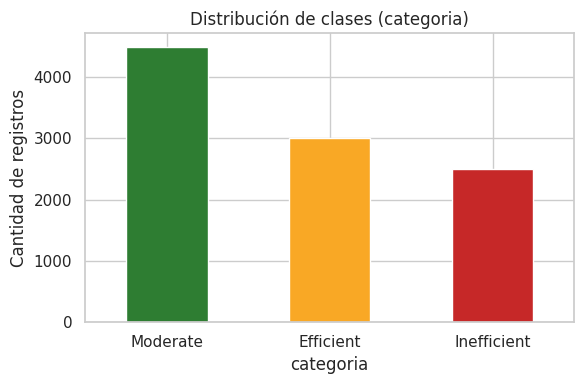

In [18]:
# 7.1 Balance de clases
fig, ax = plt.subplots(figsize=(6, 4))
df["categoria"].value_counts().plot(kind="bar", color=["#2E7D32", "#F9A825", "#C62828"], ax=ax)
ax.set_title("Distribución de clases (categoria)")
ax.set_ylabel("Cantidad de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "01_balance_clases.png"), dpi=120)
plt.show()

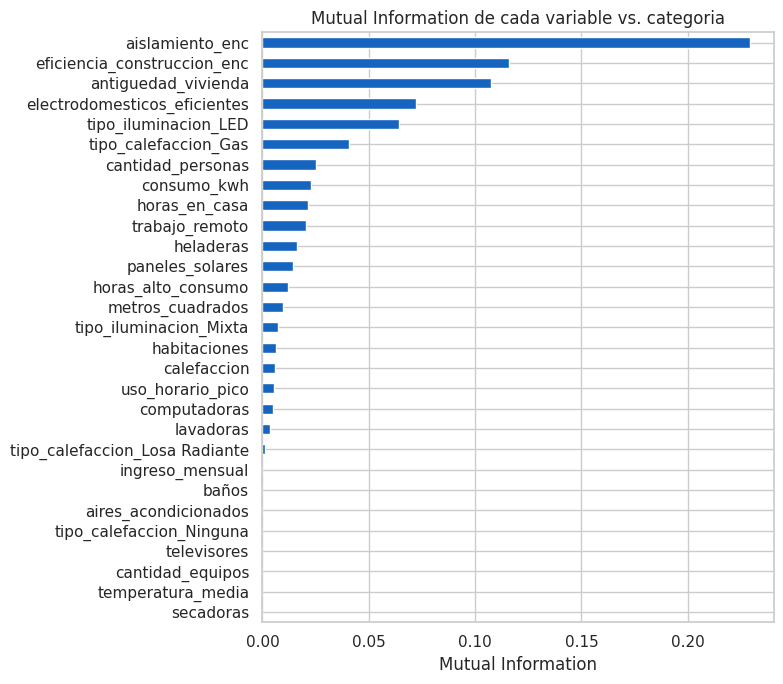

In [19]:
# 7.2 Mutual Information Ranking
fig, ax = plt.subplots(figsize=(8, 7))
mi_ranking.sort_values().plot(kind="barh", color="#1565C0", ax=ax)
ax.set_title("Mutual Information de cada variable vs. categoria")
ax.set_xlabel("Mutual Information")
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "02_mutual_information.png"), dpi=120)
plt.show()

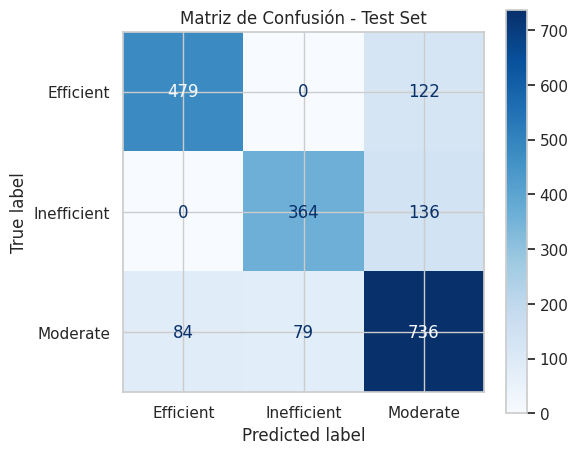

Gráficos generados y guardados en: ./visualizaciones


In [20]:
# 7.3 Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=le_y.classes_, cmap="Blues", ax=ax
)
ax.set_title("Matriz de Confusión - Test Set")
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "03_matriz_confusion.png"), dpi=120)
plt.show()

print(f"Gráficos generados y guardados en: {charts_dir}")